In [1]:
import rosalia as rs

In [2]:
rs.__file__

'/Users/aborlaff/NASA/ROSALIA/rosalia/__init__.py'

In [3]:
import ephessos as ep
print(ep.__file__)

/Users/aborlaff/NASA/EPHESSOS/ephessos/__init__.py


<Axes: xlabel='Right Ascension (degree)', ylabel='Declination (degree)'>

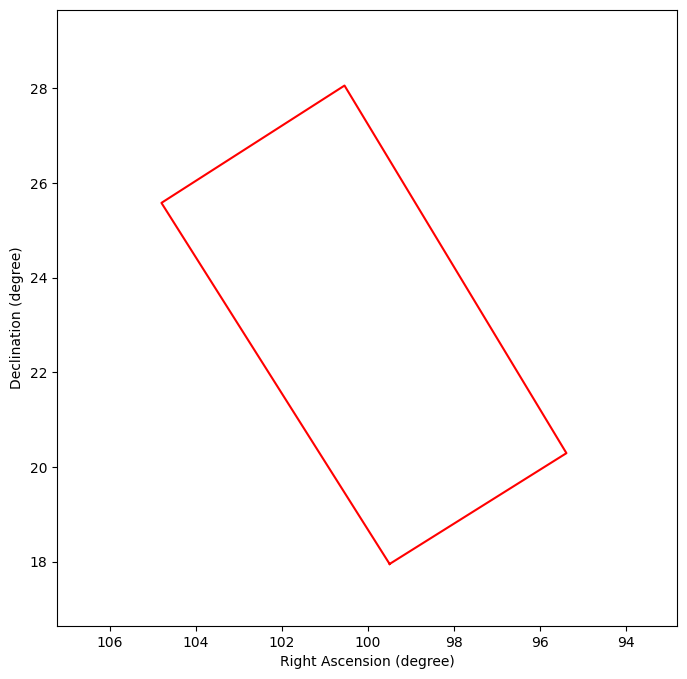

In [19]:
# Telescope definition object 
# telescope = {"pointing": [RA_TARG, DEC_TARG], "PA_Y": PA_Y, "detector_shape": [NAXIS1, NAXIS2], "pixscale": pixscale,
#              "R_mirror": R_mirror, "OBSLOC": OBSLOC, "EXPSTART": EXPSTART, "EXPTIME": EXPTIME}

class exposure():
    
    def __init__(self, filename=None, telescope=None):
        import numpy as np 
        from astropy.time import Time
        import astropy.units as u

        if telescope is not None: 
            
            self.TELESCOP = telescope['TELESCOP']
            self.DATA_SHAPE = telescope['DATA_SHAPE']
            self.RA_TARG = telescope["pointing"][0]
            self.DEC_TARG = telescope["pointing"][1]
            self.PA = telescope['PA_Y']
            self.EXPSTART = telescope['EXPSTART']
            self.EXPTIME = telescope['EXPTIME']
            self.EXPMID = (Time(self.EXPSTART, format="mjd") + self.EXPTIME*u.s/2).mjd
            self.EXPEND = (Time(self.EXPSTART, format="mjd") + self.EXPTIME*u.s).mjd
            # self.PHYSPIX = telescope['PHYSPIX']
            self.PIXSCALE = telescope['PIXSCALE']
            # self.EXPSTART_ISOT = 
            self.OBSLOC = telescope['OBSLOC']
            self.FILTER_IDENTITY = rs.telescopes.find_filter_in_svo(wavelength=telescope["FILTER_PARAMS"]["NAME"],
                                                                    telescope=telescope["FILTER_PARAMS"]["TELESCOPE"],
                                                                    instrument=telescope["FILTER_PARAMS"]["INSTRUMENT"],
                                                                    detector=telescope["FILTER_PARAMS"]["DETECTOR"], verbose=False)
            # self.XYZ_HELIO_POS = exposure_identity['XYZ_HELIO_POS']
            self.SCIEXTS = [0]

            header = rs.utils.create_custom_wcs(crpix=np.array(self.DATA_SHAPE)/2, 
                                                         crval=[self.RA_TARG, self.DEC_TARG], 
                                                         cdelt=[-self.PIXSCALE,self.PIXSCALE], 
                                                         crota=[-self.PA,-self.PA], 
                                                         projection="TAN")
            
            header["NAXIS1"] = self.DATA_SHAPE[0]
            header["NAXIS2"] = self.DATA_SHAPE[1]

            from astropy.wcs import wcs as astropy_wcs
            self.ASTROPYWCS = [astropy_wcs.WCS(header)]
            self.FPA_NEAR_RADIUS = self.get_max_angular_size()/4
            import os 
            self.FILENAME = os.getcwd() + "/" + self.TELESCOP + "_RA_" + '{:07.3f}'.format(self.RA_TARG) +\
                                     "_DEC_" + '{:07.3f}'.format(self.DEC_TARG) +\
                                     "_MJD_" + '{:07.5f}'.format(self.EXPSTART) +\
                                     "_PA_" + '{:06.2f}'.format(self.PA) + ".fits"

        if filename is not None:
            exposure_identity = rs.utils.exposure_inspector(filename, lite=True)
        
            self.FILENAME = exposure_identity['FILENAME']
            self.TELESCOP = exposure_identity['TELESCOP']
            self.INSTRUME = exposure_identity['INSTRUME']
            self.DETECTOR = exposure_identity['DETECTOR']
            self.RA_TARG = exposure_identity['RA_TARG']
            self.DEC_TARG = exposure_identity['DEC_TARG']
            self.EXPSTART = exposure_identity['EXPSTART']
            self.EXPTIME = exposure_identity['EXPTIME']
            self.EXPMID = (Time(self.EXPSTART, format="mjd") + self.EXPTIME*u.s/2).mjd
            self.EXPEND = (Time(self.EXPSTART, format="mjd") + self.EXPTIME*u.s).mjd
            self.BUNIT = exposure_identity['BUNIT']
            self.EXPSTART_ISOT = exposure_identity['EXPSTART_ISOT']
            self.PA = exposure_identity['PA']
            # self.SCA = exposure_identity['SCA']
            self.HST_TYPE = exposure_identity['HST_TYPE']
            self.FILTER = exposure_identity['FILTER']
            self.FILTER_IDENTITY = exposure_identity['FILTER_IDENTITY']
            # self.PHYSPIX = exposure_identity['PHYSPIX']
            self.PIXSCALE = exposure_identity['PIXSCALE']
            self.SCIEXTS = exposure_identity['SCIEXTS']
            self.DATA_SHAPE = exposure_identity['DATA_SHAPE']
            self.ASTROPYWCS = exposure_identity['ASTROPYWCS']
            self.FILETYPE = exposure_identity['FILETYPE']
            self.XYZ_HELIO_POS = exposure_identity['XYZ_HELIO_POS']
            self.FPA_NEAR_RADIUS = self.get_max_angular_size()/4

    def get_detector_corners(self):
        detector_corners = []
        for i in range(len(self.SCIEXTS)):
            detector_corners.append(rs.detectors.get_detector_corners(self.ASTROPYWCS[i]))
        return(detector_corners)
    
    def get_max_angular_size(self):
        return(rs.utils.find_max_angular_size_of_image(wcs=self.ASTROPYWCS, ra_cen=self.RA_TARG, dec_cen=self.DEC_TARG))
    

    def plot_footprint(self, ax=None, color='red', label=None, **kwargs):
        import numpy as np
        import matplotlib.pyplot as plt
        
        ra_dec_constraints = rs.gaia.find_ra_dec_constraints(self.RA_TARG, self.DEC_TARG, radius=self.FPA_NEAR_RADIUS, verbose=False)
        exp_corners = self.get_detector_corners()

        if ax is None:
            fig, ax = plt.subplots(figsize=(8,8))
        for i in range(len(self.SCIEXTS)):
            x = np.array(exp_corners[i]["corners_world"][:,0].tolist() + [exp_corners[i]["corners_world"][0,0]])
            y = np.array(exp_corners[i]["corners_world"][:,1].tolist() + [exp_corners[i]["corners_world"][0,1]])
            ax.plot(x, y, color=color, label=label, **kwargs)
            ax.set_xlim(ra_dec_constraints["ra_max"], ra_dec_constraints["ra_min"])
            ax.set_ylim(ra_dec_constraints["dec_min"], ra_dec_constraints["dec_max"])
            ax.set_xlabel("Right Ascension (degree)")
            ax.set_ylabel("Declination (degree)")
        return(ax)
    
    def find_nearby_ssos(self):
        import ephessos as ep 
        sso_cone_search = ep.core.cone_search(ra=self.RA_TARG, dec=self.DEC_TARG, mjd=self.EXPSTART, search_radius=self.FPA_NEAR_RADIUS, verbose=False)
        return(sso_cone_search)

    def get_nearby_sources(self, g_mag_max=15, verbose=False):
        hybrid_catalog = rs.psf.get_hybrid_catalog(ra=self.RA_TARG, dec=self.DEC_TARG,
                                                   radius=1,
                                                   lambda_ref=self.FILTER_IDENTITY["filter_lambda_ref"],
                                                   MJD=self.EXPSTART,
                                                   observer=self.TELESCOP,
                                                   g_mag_max = g_mag_max,
                                                   verbose=verbose,
                                                   query_filename=self.FILENAME.replace(".fits", ".csv"))
        return(hybrid_catalog)
        

    def get_nearby_ssos(self, time_step="30s"):
        import ephessos as ep
        cone_search = ep.core.cone_search(ra=self.RA_TARG, dec=self.DEC_TARG, mjd=self.EXPSTART, search_radius=self.FPA_NEAR_RADIUS*60*60, observatory=self.OBSLOC, verbose=True)
        ephessos_df = ep.core.ephessos(sso_search=cone_search, mjd_start=self.EXPSTART, mjd_end=self.EXPEND, step_size=time_step)
        return(ephessos_df)



TELESCOP="STARFOX"
RA_TARG = 100
DEC_TARG = 23
PA_Y = 32
NAXIS1=2048
NAXIS2=4096
PIXSCALE=8/60/60
R_mirror=1
OBSLOC=273
EXPSTART=61000
EXPTIME=10
FILTER_PARAMS={"NAME": "F606W", "TELESCOPE": "HST", "INSTRUMENT": "ACS", "DETECTOR": "WFC"}

telescope = {"TELESCOP":TELESCOP, "pointing": [RA_TARG, DEC_TARG], "PA_Y": PA_Y, "DATA_SHAPE": [NAXIS1, NAXIS2], "PIXSCALE": PIXSCALE,
             "R_mirror": R_mirror, "FILTER_PARAMS":FILTER_PARAMS, "OBSLOC": OBSLOC, "EXPSTART": EXPSTART, "EXPTIME": EXPTIME}

custom_exposure = exposure(telescope=telescope)
custom_exposure.get_detector_corners()
custom_exposure.plot_footprint()

In [20]:
custom_exposure.ASTROPYWCS[0].proj_plane_pixel_scales()

[<Quantity 0.00222222 deg>, <Quantity 0.00222222 deg>]

In [21]:
exposure_identity = rs.utils.exposure_inspector(filename, lite=True)
exposure_identity["SCIEXTS"]

[1]

In [22]:
filename="/Users/aborlaff/NASA/AURELIEN/UFO/MAST_2022-05-05T1554/HST/ic1601hsq/ic1601hsq_flt.fits"
hst_exp = exposure(filename="/Users/aborlaff/NASA/AURELIEN/UFO/MAST_2022-05-05T1554/HST/ic1601hsq/ic1601hsq_flt.fits")


In [26]:
hst_exp.OBSLOC

AttributeError: 'exposure' object has no attribute 'OBSLOC'

In [8]:
custom_exposure.get_detector_corners()


[{'corners_pix': array([[   0,    0],
         [2048,    0],
         [2048, 4096],
         [   0, 4096]]),
  'corners_world': array([[ 99.49463742,  17.95009874],
         [ 95.38366005,  20.29062089],
         [100.54317388,  28.05425597],
         [104.79909317,  25.57641679]])}]

In [9]:
nearby_catalog = custom_exposure.get_nearby_sources()

Status messages could not be retrieved
INFO: Retrieving tables... [astroquery.utils.tap.core]


ConnectionResetError: [Errno 54] Connection reset by peer

In [ ]:
# Zodiacal light STScI
# roman_notebooks/notebooks/background_visualization_tool/rbt.py     def read_bkg_data_from_url(self, cache_file, verbose=False):

In [ ]:
import glob
roman_fits = glob.glob("/Users/aborlaff/NASA/ROSALIA_DEVEL/notebooks/CAR/WFI*[0-9].fits")

for i in range(len(roman_fits)):
    print(roman_fits[i])
    roman_exposure = exposure(roman_fits[i])
    roman_exposure.plot_footprint()
    roman_exposure.find_nearby_ssos()

In [ ]:
(/60/60*4096)**2

In [ ]:
# roman_exposure.get_detector_corners()
rs.utils.find_max_angular_size_of_image(wcs=roman_exposure.ASTROPYWCS)    

In [ ]:
ep.core.get_last_mpcorb()

In [ ]:
exp_corners[0]["corners_world"][:,0].tolist()

In [ ]:
import pympc 
pympc.update_catalogue()